## **BASE DE DATOS SOBRE LA EL IMPACTO DE LA IA EN EL EMPLEO Y LOS SALARIOS** ##

In [2]:
# importamos las librerias necesarios que vamos a usar en este analisis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# estas son las libreria a usar en el analisis de datos.


In [3]:
# Importamos la base de datos que vamos a usar para este analisis que lo tenemos en archivo csv

futuro_IA = pd.read_csv("Future of Jobs AI Dataset.csv")

In [4]:
# Verificamos que la base de datos de haya cargado de manera correcta

futuro_IA.head()

,job_title,country,experience_level,education_level,year,salary,ai_risk_score,primary_skill,skill_demand_score,job_openings,job_survival_class,salary_bucket,ai_risk_category
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk


## **DESCRIPCION DE LOS DATOS** ##

In [10]:
futuro_IA.head()

,job_title,country,experience_level,education_level,year,salary,ai_risk_score,primary_skill,skill_demand_score,job_openings,job_survival_class,salary_bucket,ai_risk_category
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk


In [11]:
futuro_IA.shape

(12343, 13)

In [12]:
futuro_IA.info()

<class 'pandas.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           12343 non-null  str    
 1   country             12343 non-null  str    
 2   experience_level    12343 non-null  str    
 3   education_level     12343 non-null  str    
 4   year                12343 non-null  int64  
 5   salary              12343 non-null  float64
 6   ai_risk_score       12343 non-null  float64
 7   primary_skill       12343 non-null  str    
 8   skill_demand_score  12343 non-null  int64  
 9   job_openings        12343 non-null  int64  
 10  job_survival_class  12343 non-null  int64  
 11  salary_bucket       12343 non-null  str    
 12  ai_risk_category    12343 non-null  str    
dtypes: float64(2), int64(4), str(7)
memory usage: 1.2 MB


Se realizó una exploración inicial del dataset con el fin de comprender su estructura general.
El conjunto de datos cuenta con 12.343 registros y 13 variables, lo que permite un análisis suficientemente robusto.

A través del método .info(), se identificaron los tipos de datos de cada columna, evidenciando la presencia de variables tanto numéricas como categóricas.
Esta revisión es fundamental para detectar posibles inconsistencias en los tipos de datos antes de proceder con el análisis.

In [23]:
futuro_IA = futuro_IA.rename(columns={
    "job_title": "puesto_trabajo",
    "country": "pais",
    "experience_level": "nivel_experiencia",
    "education_level": "nivel_educacion",
    "year": "anio",
    "salary": "salario_usd",
    "ai_risk_score": "probabilidad_riesgo_ia",
    "primary_skill": "habilidad_principal",
    "skill_demand_score": "demanda_habilidad",
    "job_openings": "vacantes",
    "job_survival_class": "estabilidad_laboral",
    "salary_bucket": "nivel_salario",
    "ai_risk_category": "nivel_riesgo_ia"
})

In [24]:
futuro_IA.head()

,puesto_trabajo,pais,nivel_experiencia,nivel_educacion,anio,salario_usd,probabilidad_riesgo_ia,habilidad_principal,demanda_habilidad,vacantes,estabilidad_laboral,nivel_salario,nivel_riesgo_ia
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk


Se realizó la traducción y estandarización de los nombres de las variables a español, con el objetivo de mejorar la comprensión del dataset y facilitar su interpretación desde una perspectiva de negocio.

Los nuevos nombres permiten identificar de forma más intuitiva el significado de cada variable, lo que contribuye a un análisis más claro y una mejor comunicación de los resultados.

In [25]:
futuro_IA.isnull().sum()

puesto_trabajo            0
pais                      0
nivel_experiencia         0
nivel_educacion           0
anio                      0
salario_usd               0
probabilidad_riesgo_ia    0
habilidad_principal       0
demanda_habilidad         0
vacantes                  0
estabilidad_laboral       0
nivel_salario             0
nivel_riesgo_ia           0
dtype: int64

Se realizó la verificación de valores faltantes en el dataset.
No se identificaron valores nulos en ninguna de las columnas, lo cual indica una alta calidad inicial de los datos y permite continuar con el análisis sin necesidad de imputaciones o eliminación de registros.

In [26]:
futuro_IA.duplicated().sum()

np.int64(0)

Se evaluó la presencia de registros duplicados dentro del dataset.
No se encontraron duplicados, lo que garantiza que cada fila representa una observación única.

In [27]:
futuro_IA.dtypes

puesto_trabajo                str
pais                          str
nivel_experiencia             str
nivel_educacion               str
anio                        int64
salario_usd               float64
probabilidad_riesgo_ia    float64
habilidad_principal           str
demanda_habilidad           int64
vacantes                    int64
estabilidad_laboral         int64
nivel_salario                 str
nivel_riesgo_ia               str
dtype: object

Se revisaron los tipos de datos de cada variable para asegurar su correcta interpretación.
Las variables categóricas se encuentran en formato str, mientras que las variables numéricas están correctamente tipadas como int o float.
Esta validación es importante para garantizar que los análisis posteriores (estadísticos y gráficos) sean adecuados.

In [28]:
for col in futuro_IA.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(futuro_IA[col].unique())


puesto_trabajo:
<StringArray>
[       'Data Scientist',     'Software Engineer',          'Data Analyst',
       'DevOps Engineer', 'Cybersecurity Analyst',        'Cloud Engineer',
      'Business Analyst',         'AI Researcher',           'ML Engineer',
       'Product Manager']
Length: 10, dtype: str

pais:
<StringArray>
['USA', 'India', 'Canada', 'UK', 'Germany', 'Australia']
Length: 6, dtype: str

nivel_experiencia:
<StringArray>
['Senior', 'Mid', 'Entry']
Length: 3, dtype: str

nivel_educacion:
<StringArray>
['Master', 'Bachelor', 'PhD']
Length: 3, dtype: str

habilidad_principal:
<StringArray>
[       'Python',          'Java',           'SQL',        'Docker',
      'Security',           'AWS',         'Excel', 'Deep Learning',
      'Strategy']
Length: 9, dtype: str

nivel_salario:
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

nivel_riesgo_ia:
<StringArray>
['Medium Risk', 'Low Risk', 'High Risk']
Length: 3, dtype: str


C:\Users\marin\AppData\Local\Temp\ipykernel_12796\3622627485.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in futuro_IA.select_dtypes(include='object').columns:


Se realizó una revisión de las variables categóricas para identificar posibles inconsistencias en los valores, tales como diferencias en mayúsculas, espacios en blanco o categorías duplicadas.
Este paso es clave para evitar errores en el análisis y garantizar la correcta agrupación de los datos.

Se evidencia que no tenemos variables categoricas fuera del estandar conocido.

In [29]:
futuro_IA.describe()

,anio,salario_usd,probabilidad_riesgo_ia,demanda_habilidad,vacantes,estabilidad_laboral
count,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000
mean,2025.054525,34553.729166,0.396008,79.453374,25223.652029,1.310054
std,6.058714,18024.702961,0.187665,11.483535,14163.309081,0.658417
min,2015.000000,3875.170000,0.050000,60.000000,1002.000000,0.000000
25%,2020.000000,21331.405000,0.260000,70.000000,12993.000000,1.000000
50%,2025.000000,31573.380000,0.360000,79.000000,24896.000000,1.000000
75%,2030.000000,45307.845000,0.490000,89.000000,37440.500000,2.000000
max,2035.000000,113589.260000,0.850000,99.000000,49998.000000,2.000000


Se realizó un análisis descriptivo de las variables numéricas del dataset con el objetivo de identificar posibles valores atípicos o inconsistencias.

A través de medidas como la media, desviación estándar, valores mínimos y máximos, se evaluó la coherencia de los datos, permitiendo detectar posibles errores o valores extremos que puedan afectar el análisis.

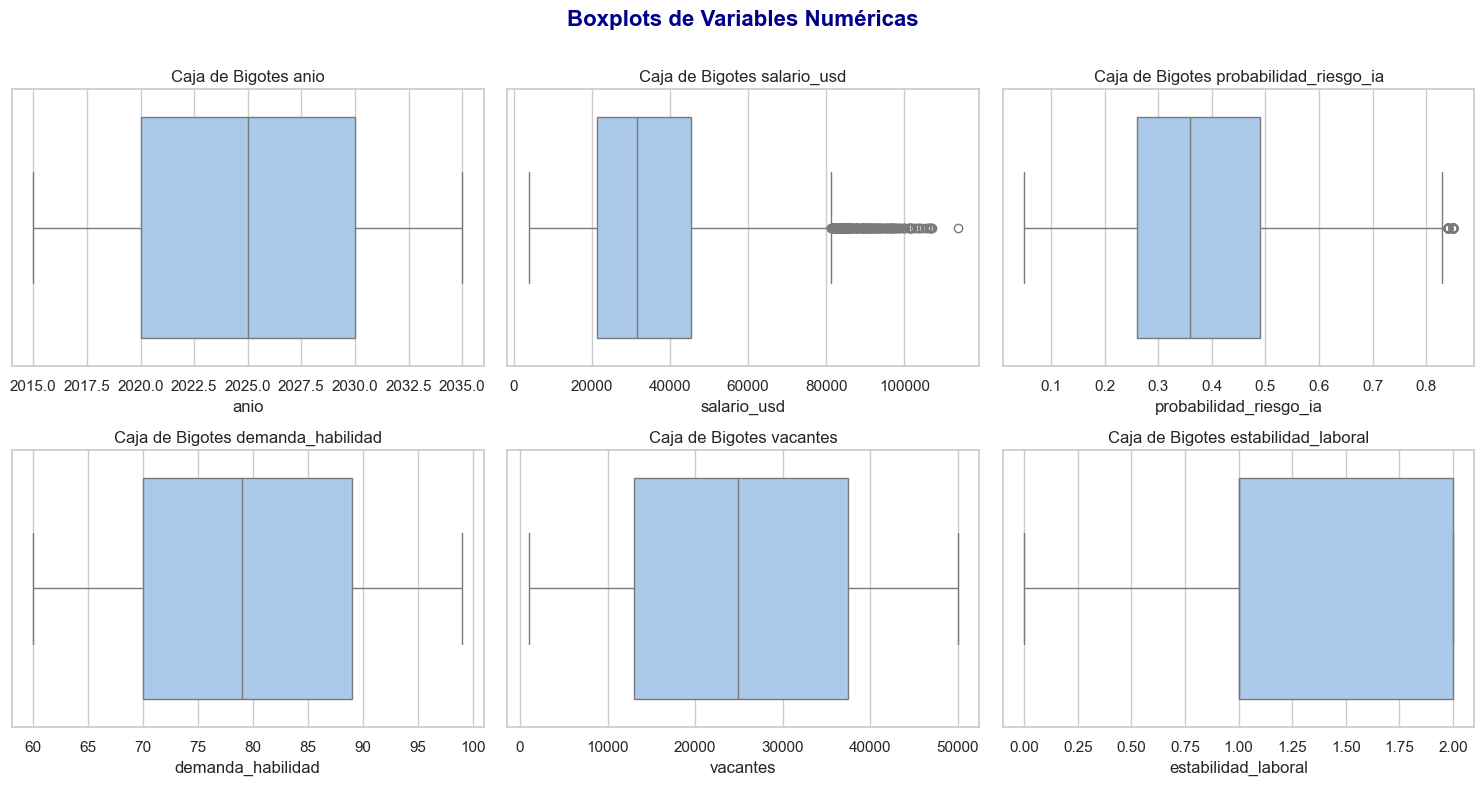

In [ ]:
# columnas numéricas
cols = futuro_IA.select_dtypes(include=['int64', 'float64']).columns

# estilo pastel
sns.set(style="whitegrid", palette="pastel")

# crear lienzo 3x2
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# graficar
for i, col in enumerate(cols):
    sns.boxplot(x=futuro_IA[col], ax=axes[i])
    axes[i].set_title(f'Caja de Bigotes {col}')

# título general del gráfico
fig.suptitle(
    'Boxplots de Variables Numéricas',
    fontsize=16,
    fontweight='bold',
    color='darkblue'
)

# ajustar espacios
plt.tight_layout()

# ajustar posición del título para que no se encime
plt.subplots_adjust(top=0.88)

plt.show()

A partir del análisis exploratorio mediante diagramas de caja, se evaluó la distribución de las principales variables numéricas del dataset.

Se identificó que variables como el salario y las vacantes presentan una alta dispersión, lo que evidencia diferencias significativas dentro del mercado laboral analizado. En particular, el salario muestra una distribución sesgada hacia valores altos, indicando la existencia de algunos empleos con remuneraciones considerablemente superiores al promedio.

Por otro lado, variables como la demanda de habilidades y la probabilidad de riesgo por inteligencia artificial presentan distribuciones más concentradas, lo que sugiere comportamientos más homogéneos entre los distintos roles.

Finalmente, se observó que algunas variables, como la estabilidad laboral, corresponden a categorías discretas, por lo que su análisis requiere enfoques diferentes a los utilizados para variables continuas.

El mercado laboral analizado presenta una alta variabilidad en términos salariales, donde unos pocos empleos concentran los salarios más altos, mientras que la mayoría se mantiene en rangos medios, lo que evidencia una distribución desigual de ingresos.

Aunque la demanda de habilidades es relativamente alta y homogénea, el riesgo de automatización varía entre los distintos roles, lo que sugiere que no todos los empleos tienen el mismo nivel de exposición frente al avance de la inteligencia artificial.

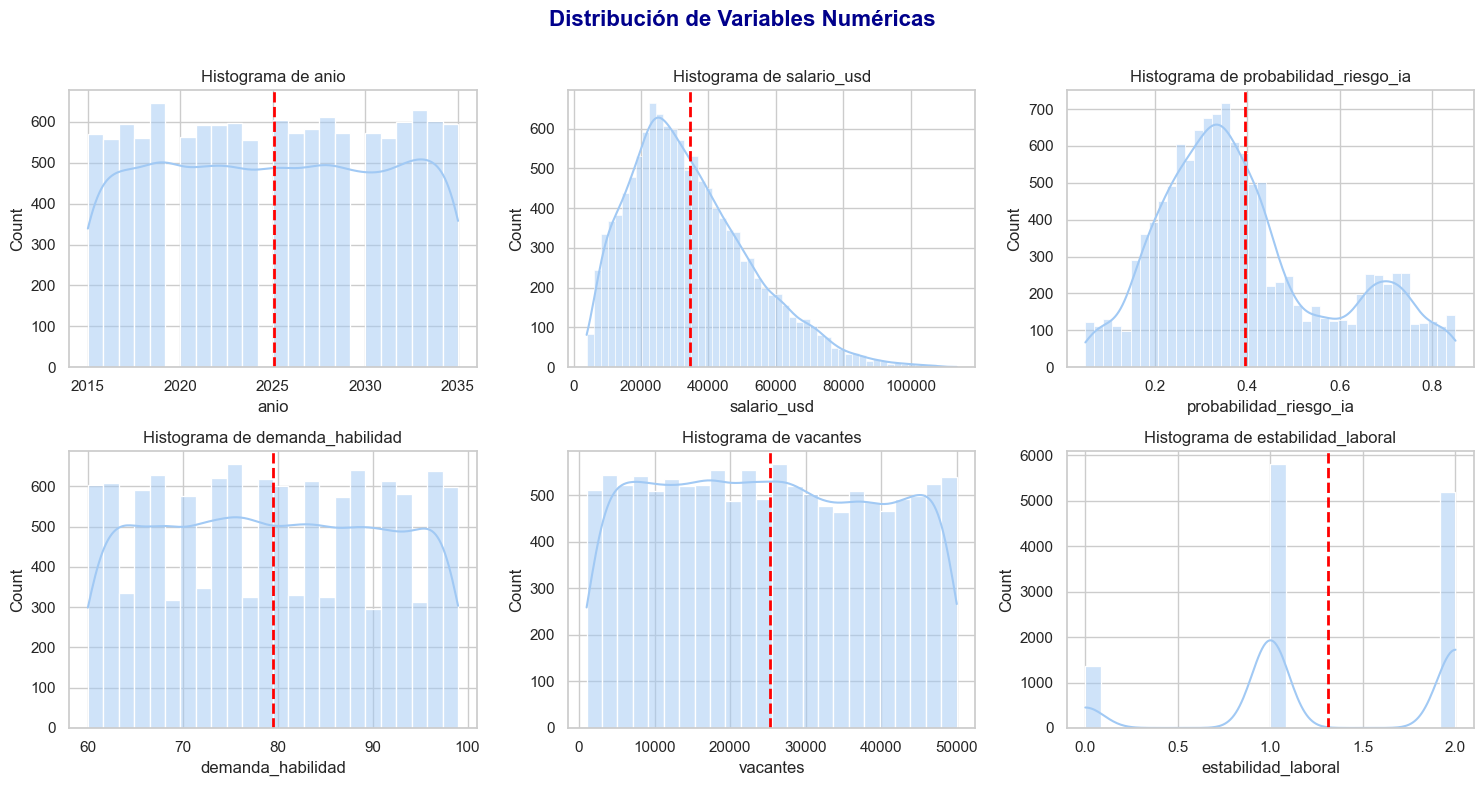

In [36]:
# columnas numéricas
cols = futuro_IA.select_dtypes(include=['int64', 'float64']).columns

# estilo
sns.set(style="whitegrid", palette="pastel")

# lienzo
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# histogramas
for i, col in enumerate(cols):
    media = futuro_IA[col].mean()
    
    sns.histplot(futuro_IA[col], kde=True, ax=axes[i])
    
    # línea de la media
    axes[i].axvline(media, color='red', linestyle='--', linewidth=2)
    
    axes[i].set_title(f'Histograma de {col}')

# título general centrado
fig.suptitle(
    'Distribución de Variables Numéricas',
    fontsize=16,
    fontweight='bold',
    color='darkblue'
)

# ajustar layout
plt.tight_layout()

# espacio para el título
plt.subplots_adjust(top=0.88)

plt.show()

El análisis de las distribuciones revela que el mercado laboral estudiado presenta características heterogéneas, especialmente en términos salariales y de riesgo de automatización.

El salario muestra una distribución altamente sesgada, evidenciando una concentración de empleos en rangos medios con una minoría de roles altamente remunerados, lo que sugiere desigualdad en la estructura salarial.

Por otro lado, la probabilidad de riesgo por inteligencia artificial no presenta una distribución uniforme, sino que parece segmentarse en diferentes grupos de exposición, lo que indica que ciertos perfiles laborales están significativamente más vulnerables que otros.

En contraste, variables como la demanda de habilidades y las vacantes muestran comportamientos más homogéneos, lo que podría indicar una distribución más equilibrada en términos de oportunidades y requerimientos del mercado.

Existe una clara desigualdad en la distribución de los salarios, donde la mayoría de los empleos se concentran en niveles medios, mientras que un pequeño grupo alcanza remuneraciones significativamente superiores.

El riesgo de automatización no es uniforme entre los distintos roles, lo que evidencia la existencia de segmentos laborales con diferentes niveles de vulnerabilidad frente a la inteligencia artificial.

In [37]:
from scipy.stats import kstest
import numpy as np

for col in cols:
    data = futuro_IA[col]
    
    # estandarizar
    data_std = (data - np.mean(data)) / np.std(data)
    
    stat, p = kstest(data_std, 'norm')
    
    print(f"\nVariable: {col}")
    print(f"Estadístico: {stat:.4f}")
    print(f"p-valor: {p:.4f}")
    
    if p > 0.05:
        print("→ Aproximadamente normal")
    else:
        print("→ No sigue distribución normal")


Variable: anio
Estadístico: 0.0812
p-valor: 0.0000
→ No sigue distribución normal

Variable: salario_usd
Estadístico: 0.0680
p-valor: 0.0000
→ No sigue distribución normal

Variable: probabilidad_riesgo_ia
Estadístico: 0.1103
p-valor: 0.0000
→ No sigue distribución normal

Variable: demanda_habilidad
Estadístico: 0.0697
p-valor: 0.0000
→ No sigue distribución normal

Variable: vacantes
Estadístico: 0.0574
p-valor: 0.0000
→ No sigue distribución normal

Variable: estabilidad_laboral
Estadístico: 0.2725
p-valor: 0.0000
→ No sigue distribución normal


Se realizaron pruebas de normalidad utilizando el test de Kolmogorov-Smirnov para evaluar la distribución de las variables numéricas.

Los resultados indican que todas las variables presentan p-valores inferiores a 0.05, lo que lleva a rechazar la hipótesis nula de normalidad. Esto implica que ninguna de las variables sigue una distribución normal.

Estos resultados son consistentes con el análisis visual previo mediante histogramas, donde se identificaron distribuciones sesgadas, uniformes o discretas, particularmente en variables como el salario, las vacantes y la demanda de habilidades.

Es importante destacar que la variable de estabilidad laboral, al ser de tipo discreto, no es adecuada para este tipo de pruebas, lo que refuerza la necesidad de seleccionar correctamente las técnicas estadísticas según la naturaleza de los datos.

Dado que las variables no siguen una distribución normal, el análisis posterior deberá basarse en métodos no paramétricos, como la correlación de Spearman, en lugar de técnicas que asumen normalidad como la correlación de Pearson.

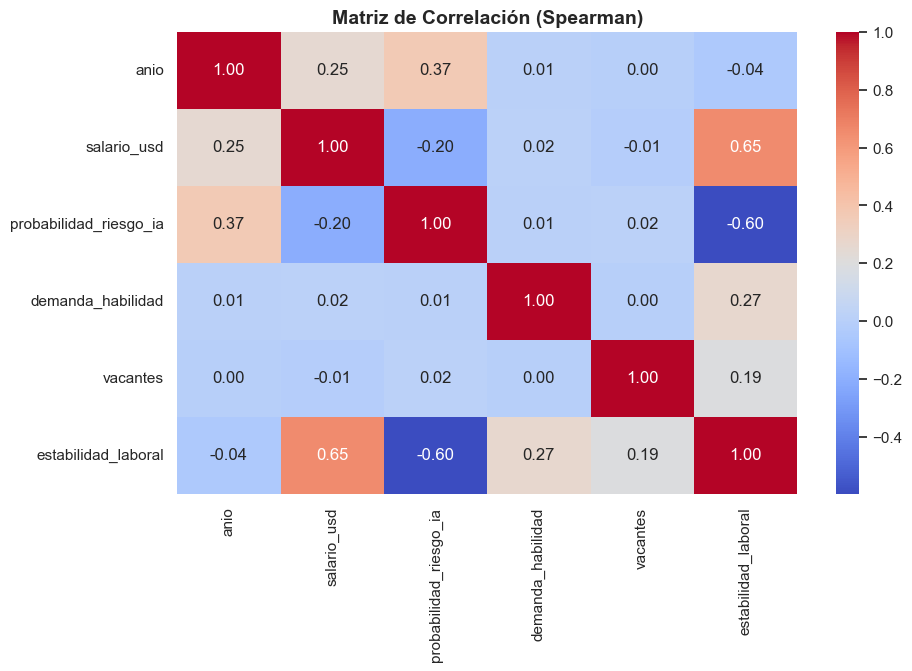

In [40]:
# seleccionar solo columnas numéricas
df_num = futuro_IA.select_dtypes(include=['int64', 'float64'])

# correlación Spearman
corr = df_num.corr(method='spearman')

# gráfico
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Matriz de Correlación (Spearman)", fontsize=14, fontweight='bold')
plt.show()

1. Salario vs Estabilidad laboral (0.65)

Existe una relación positiva fuerte entre el salario y la estabilidad laboral, lo que indica que los empleos mejor remunerados tienden a ofrecer mayor seguridad. Esto sugiere que el nivel salarial puede ser un indicador importante de la permanencia y solidez de un puesto de trabajo.

2. Salario vs Riesgo de IA (-0.20)

Se observa una relación negativa débil entre el salario y el riesgo de automatización, lo que indica que los empleos con mayores ingresos tienden a estar menos expuestos a ser reemplazados por inteligencia artificial, aunque esta relación no es determinante.

3. Riesgo de IA vs Estabilidad laboral (-0.60)

Existe una relación negativa fuerte entre el riesgo de automatización y la estabilidad laboral, evidenciando que los trabajos más expuestos a la inteligencia artificial presentan menores niveles de seguridad y mayor vulnerabilidad en el mercado laboral.

4. Demanda de habilidad vs Estabilidad laboral (0.27)

Se identifica una relación positiva moderada entre la demanda de habilidades y la estabilidad laboral, lo que sugiere que los empleos que requieren competencias más demandadas tienden a ser más estables en el tiempo.

5. Vacantes vs Estabilidad laboral (0.19)

La relación entre el número de vacantes y la estabilidad laboral es débilmente positiva, lo que indica que una mayor disponibilidad de empleos no necesariamente garantiza mayor seguridad laboral.

6. Salario vs Demanda de habilidad (0.02)

No se evidencia una relación significativa entre el salario y la demanda de habilidades, lo que sugiere que una mayor demanda de una habilidad no implica necesariamente una mejor remuneración.

7. Vacantes vs Salario (-0.01)

No existe una relación significativa entre el número de vacantes y el salario, lo que indica que la cantidad de oportunidades disponibles no está directamente asociada con el nivel de ingresos.


8. Demanda de habilidad vs Riesgo de IA (0.01)

No se observa una relación relevante entre la demanda de habilidades y el riesgo de automatización, lo que sugiere que una habilidad demandada no necesariamente está protegida frente al avance de la inteligencia artificial.

Las variables con mayor impacto en el mercado laboral son el salario, la estabilidad laboral y el riesgo de automatización por inteligencia artificial.

Estas variables presentan las relaciones más significativas dentro del análisis, evidenciando que los empleos mejor remunerados tienden a ser más estables y menos susceptibles a ser reemplazados por tecnologías emergentes.

Por otro lado, el riesgo de automatización se posiciona como un factor determinante en la seguridad del empleo, afectando directamente la estabilidad laboral.

En contraste, variables como la demanda de habilidades y el número de vacantes muestran una menor influencia en las dinámicas principales del mercado, lo que sugiere que la cantidad de oportunidades disponibles no es el factor más relevante al momento de evaluar la calidad o seguridad de un empleo.

En conjunto, estos hallazgos permiten concluir que el mercado laboral no solo está determinado por la disponibilidad de empleos, sino por la combinación entre remuneración, estabilidad y nivel de exposición a la automatización.